In [25]:
!pip install cclib
import numpy as np
import cclib
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib as mpl
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


# New version

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import pandas as pd
table=pd.read_csv('/content/drive/My Drive/Colab Notebooks/AllData.csv', index_col=[0])
table.reset_index(inplace=True)

In [29]:
dd = table['System'].duplicated().sum()
display(table,'Count of duplicated systems: {}'.format(dd))

if dd != 0:
    display('Duplicated : ',table[table.duplicated()]['System'])
    table.drop_duplicates(subset='System',inplace=True)
    ## dd = table['System'].duplicated().sum()
    ## display(table,'Count of duplicated systems: {}'.format(dd))

,System,SCF Energy,S1,S2,S3,T1,T2,T3,Function
0,CSH_CNHH_CH_CNOO_CNHH_CSH,-1343.702596,2.40,3.38,3.91,1.58,2.75,2.80,-0.76
1,CSH_CNHH_CH_CCN_CNHH_CSH,-1231.458912,2.33,3.95,4.40,1.52,2.48,4.04,-0.70
2,CSH_CNHH_CH_CCFFF_CNHH_CSH,-1476.266670,2.50,4.09,4.64,1.64,2.59,4.15,-0.78
3,CSH_CNHH_CH_CCl_CNHH_CSH,-1598.819400,2.90,4.28,4.54,1.97,2.78,4.47,-1.04
4,CSH_CNHH_CH_CF_CNHH_CSH,-1238.461866,2.89,4.40,4.55,1.95,2.97,4.38,-1.01
...,...,...,...,...,...,...,...,...,...
1653,CNMeMe_CSiHHH_CCHHH_COH_COH_COCHHH,-961.052210,3.84,4.34,4.34,2.81,3.02,4.27,-1.77
1654,CNOO_COH_CNHH_CCN_CBFF_CNOO,-1087.995600,1.46,3.52,3.77,-0.16,2.48,2.64,1.78
1655,CNOO_COH_CNHH_CCN_CH_CNOO,-863.923510,1.46,3.58,3.77,-0.25,2.49,2.60,1.96
1656,CNOO_COH_CNMeMe_CCN_CH_CNOO,-942.505010,1.51,3.54,3.73,-0.33,2.46,2.67,2.17


'Count of duplicated systems: 0'

In [30]:
table['|Function|'] = table['Function'].abs()
display(table)

,System,SCF Energy,S1,S2,S3,T1,T2,T3,Function,|Function|
0,CSH_CNHH_CH_CNOO_CNHH_CSH,-1343.702596,2.40,3.38,3.91,1.58,2.75,2.80,-0.76,0.76
1,CSH_CNHH_CH_CCN_CNHH_CSH,-1231.458912,2.33,3.95,4.40,1.52,2.48,4.04,-0.70,0.70
2,CSH_CNHH_CH_CCFFF_CNHH_CSH,-1476.266670,2.50,4.09,4.64,1.64,2.59,4.15,-0.78,0.78
3,CSH_CNHH_CH_CCl_CNHH_CSH,-1598.819400,2.90,4.28,4.54,1.97,2.78,4.47,-1.04,1.04
4,CSH_CNHH_CH_CF_CNHH_CSH,-1238.461866,2.89,4.40,4.55,1.95,2.97,4.38,-1.01,1.01
...,...,...,...,...,...,...,...,...,...,...
1653,CNMeMe_CSiHHH_CCHHH_COH_COH_COCHHH,-961.052210,3.84,4.34,4.34,2.81,3.02,4.27,-1.77,1.77
1654,CNOO_COH_CNHH_CCN_CBFF_CNOO,-1087.995600,1.46,3.52,3.77,-0.16,2.48,2.64,1.78,1.78
1655,CNOO_COH_CNHH_CCN_CH_CNOO,-863.923510,1.46,3.58,3.77,-0.25,2.49,2.60,1.96,1.96
1656,CNOO_COH_CNMeMe_CCN_CH_CNOO,-942.505010,1.51,3.54,3.73,-0.33,2.46,2.67,2.17,2.17


In [32]:
table[['pos1','pos2','pos3','pos4','pos5','pos6']]=table.System.astype(str).str.split('_',expand=True)
table['System_num.pos'] = [   len(i.split('_'))   for i in table['System']  ]
#display(table)

In [33]:
def myfunc2(df,base=''):
    for n,i in enumerate(df[base]):
        if i == 6:
            pass
        elif i ==3:
            l = df.iloc[n][:]
            l[-4] = df.iloc[n]['pos1']
            l[-3] = df.iloc[n]['pos2']
            l[-2] = df.iloc[n]['pos3']
            df.iloc[n] = l
        elif i == 2:
            l = df.iloc[n][:]
            l[-5] = 'CH'
            l[-4] = df.iloc[n]['pos1']
            l[-3] = df.iloc[n]['pos2']
            l[-2] = 'CH'
            df.iloc[n] = l

    return df
## display(myfunc2(table,'System_num.pos'))
table2  = myfunc2(table,'System_num.pos')
table2['pos1'] =  [i.strip() for i in table2['pos1']] #to take out blank spaces at the beginning and the end
table2['pos2'] =  [i.strip() for i in table2['pos2']]
table2['pos3'] =  [i.strip() for i in table2['pos3']]
table2['pos4'] =  [i.strip() for i in table2['pos4']]
table2['pos5'] =  [i.strip() for i in table2['pos5']]
table2['pos6'] =  [i.strip() for i in table2['pos6']]
#table2.to_excel('ManipulatedTable_all_sys.xlsx')
#table2

In [34]:
sorted_table2 = table2.sort_values(by=['|Function|'], ascending=True)
#sorted_table2.to_excel('ManipulatedTable_all_sys.xlsx')
sorted_table2

,System,SCF Energy,S1,S2,S3,T1,T2,T3,Function,|Function|,pos1,pos2,pos3,pos4,pos5,pos6,System_num.pos
1312,CNOO_CBHH_COH,-842.438155,1.28,2.74,3.53,0.64,2.31,2.54,0.00,0.00,CNOO,CBHH,COH,CNOO,CBHH,COH,3
1461,CNOO_COH_COH_CCN_CH_CNOO,-883.774750,1.81,3.72,3.83,0.90,2.40,2.55,0.00,0.00,CNOO,COH,COH,CCN,CH,CNOO,6
362,CNOO_CCHHH_CNMeMe_CCFFF_CNHH_CNOO,-1206.773330,2.08,3.67,3.83,1.04,2.59,2.96,0.00,0.00,CNOO,CCHHH,CNMeMe,CCFFF,CNHH,CNOO,6
1041,COH_CSH_COH_CSiHHH_CNOO_CNMeMe,-1409.894916,3.21,3.64,4.03,1.61,2.52,3.15,0.00,0.00,COH,CSH,COH,CSiHHH,CNOO,CNMeMe,6
369,CNOO_CCHHH_CNMeMe_CCHHH_CNHH_CNOO,-909.039796,2.14,3.66,3.74,1.06,2.54,2.70,0.01,0.01,CNOO,CCHHH,CNMeMe,CCHHH,CNHH,CNOO,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256,COH_COH_CNHH_CNOO_CBFF_CSiHHH,-1157.195066,1.48,3.27,3.66,-0.88,1.88,3.42,3.24,3.24,COH,COH,CNHH,CNOO,CBFF,CSiHHH,6
657,CNOO_CBFF_CNMeMe_CNHH_CCFFF_CNOO,-1391.540547,1.70,3.22,3.40,-0.77,2.25,2.64,3.25,3.25,CNOO,CBFF,CNMeMe,CNHH,CCFFF,CNOO,6
279,COH_COH_CNHH_CNOO_CBFF_CBFF,-1090.598265,1.54,3.30,3.68,-0.92,2.02,3.37,3.37,3.37,COH,COH,CNHH,CNOO,CBFF,CBFF,6
280,COH_COH_CNHH_CNOO_CBFF_CBHH,-891.955693,1.56,3.25,3.56,-0.91,1.94,3.26,3.38,3.38,COH,COH,CNHH,CNOO,CBFF,CBHH,6


In [35]:
# # Column indices to modify (11 to 16 inclusive)
# start_col = 10
# end_col = 15

# # Get the column names for the range to modify
# columns_to_modify = sorted_table2.columns[start_col:end_col+1]

# # Apply the lambda function to remove 'C' from the specified columns
##sorted_table2[columns_to_modify] = sorted_table2[columns_to_modify].applymap(lambda x: x.replace('C', '', 1) if isinstance(x, str) else x)

# Define the replacement function
def replace_string(s):
    if s.startswith('C'):
        # Find the index of the first 'C'
        index = s.find('C')
        # Remove the first 'C' from the string
        s = s[:index] + s[index+1:]
    replacements = {
        'NMeMe': 'NMe$_2$',
        'NHH': 'NH$_2$',
        'OCHHH': 'OMe',
        'CHHH': 'Me',
        'SiHHH': 'SiH$_3$',
        'BHH': 'BH$_2$',
        'BFF': 'BF$_2$',
        'CFFF': 'CF$_3$',
        'NOO': 'NO$_2$'
    }
    for old, new in replacements.items():
        s = s.replace(old, new)
    return s

# Column indices to modify (11 to 16 inclusive)
start_col = 10
end_col = 15

# Get the column names for the range to modify
columns_to_modify = sorted_table2.columns[start_col:end_col+1]

# Apply the replacement function to the specified columns
sorted_table2[columns_to_modify] = sorted_table2[columns_to_modify].applymap(lambda x: replace_string(x) if isinstance(x, str) else x)

# Combine the modified columns into a single column
sorted_table2['Fulvene'] = sorted_table2[columns_to_modify].agg('_'.join, axis=1)

# Save the DataFrame to an Excel file
sorted_table2.to_excel('Table_all_sys_article.xlsx', index=False)
sorted_table2

,System,SCF Energy,S1,S2,S3,T1,T2,T3,Function,|Function|,pos1,pos2,pos3,pos4,pos5,pos6,System_num.pos,Fulvene
1312,CNOO_CBHH_COH,-842.438155,1.28,2.74,3.53,0.64,2.31,2.54,0.00,0.00,NO$_2$,BH$_2$,OH,NO$_2$,BH$_2$,OH,3,NO$_2$_BH$_2$_OH_NO$_2$_BH$_2$_OH
1461,CNOO_COH_COH_CCN_CH_CNOO,-883.774750,1.81,3.72,3.83,0.90,2.40,2.55,0.00,0.00,NO$_2$,OH,OH,CN,H,NO$_2$,6,NO$_2$_OH_OH_CN_H_NO$_2$
362,CNOO_CCHHH_CNMeMe_CCFFF_CNHH_CNOO,-1206.773330,2.08,3.67,3.83,1.04,2.59,2.96,0.00,0.00,NO$_2$,Me,NMe$_2$,CF$_3$,NH$_2$,NO$_2$,6,NO$_2$_Me_NMe$_2$_CF$_3$_NH$_2$_NO$_2$
1041,COH_CSH_COH_CSiHHH_CNOO_CNMeMe,-1409.894916,3.21,3.64,4.03,1.61,2.52,3.15,0.00,0.00,OH,SH,OH,SiH$_3$,NO$_2$,NMe$_2$,6,OH_SH_OH_SiH$_3$_NO$_2$_NMe$_2$
369,CNOO_CCHHH_CNMeMe_CCHHH_CNHH_CNOO,-909.039796,2.14,3.66,3.74,1.06,2.54,2.70,0.01,0.01,NO$_2$,Me,NMe$_2$,Me,NH$_2$,NO$_2$,6,NO$_2$_Me_NMe$_2$_Me_NH$_2$_NO$_2$
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256,COH_COH_CNHH_CNOO_CBFF_CSiHHH,-1157.195066,1.48,3.27,3.66,-0.88,1.88,3.42,3.24,3.24,OH,OH,NH$_2$,NO$_2$,BF$_2$,SiH$_3$,6,OH_OH_NH$_2$_NO$_2$_BF$_2$_SiH$_3$
657,CNOO_CBFF_CNMeMe_CNHH_CCFFF_CNOO,-1391.540547,1.70,3.22,3.40,-0.77,2.25,2.64,3.25,3.25,NO$_2$,BF$_2$,NMe$_2$,NH$_2$,CF$_3$,NO$_2$,6,NO$_2$_BF$_2$_NMe$_2$_NH$_2$_CF$_3$_NO$_2$
279,COH_COH_CNHH_CNOO_CBFF_CBFF,-1090.598265,1.54,3.30,3.68,-0.92,2.02,3.37,3.37,3.37,OH,OH,NH$_2$,NO$_2$,BF$_2$,BF$_2$,6,OH_OH_NH$_2$_NO$_2$_BF$_2$_BF$_2$
280,COH_COH_CNHH_CNOO_CBFF_CBHH,-891.955693,1.56,3.25,3.56,-0.91,1.94,3.26,3.38,3.38,OH,OH,NH$_2$,NO$_2$,BF$_2$,BH$_2$,6,OH_OH_NH$_2$_NO$_2$_BF$_2$_BH$_2$


In [36]:
#sns.violinplot(data=table2,x='Function')
#len(table2.loc[(3 == table2['System_num.pos'])])

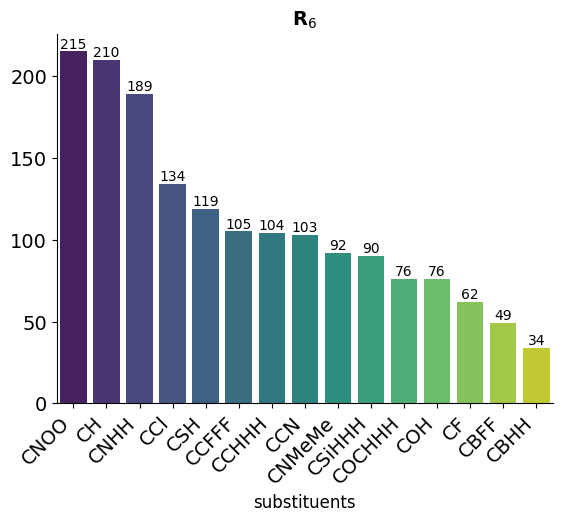

In [37]:
col  = 'pos6'
fig2=sns.countplot(data=table2, x=col, palette='viridis',
              order=table2[col].value_counts().index)
plt.xlabel('substituents',fontsize=12)
plt.ylabel('', fontweight="bold",fontsize=12)
plt.title('R$_6$',fontweight="bold", fontsize=14)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=45, ha='right', va='top')
count = table2[col].value_counts()
fig2.spines['right'].set_visible(False)
fig2.spines['top'].set_visible(False)
[plt.annotate('{}'.format(i),xy=(n,i+2),ha='center') for i,n in zip(count,range(len(count)))];
#fig2.figure.savefig('./countplot_all_R6.png', bbox_inches='tight',dpi=300)

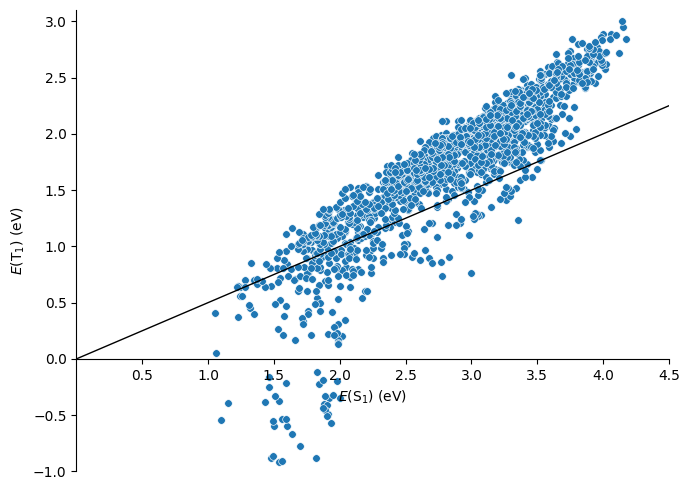

In [38]:
fig3, ax2 = plt.subplots(figsize=(7,5))
color = 'tab:blue'

sns.scatterplot(data=table2, x = 'S1',y = 'T1',s=30, ax=ax2, color=color);
## plt.rcParams['patch.edgecolor'] = color
ax2.set_xlabel(r'$E$(S$_1$) (eV)')
ax2.set_ylabel(r'$E$(T$_1$) (eV)')

delta = 0.5
x = np.linspace(0.0,table2['S1'].max()+delta)
bb  = list(map(lambda x : x*0.5,x))
ax2.plot(x,bb,lw=1,c='black')
ax2.axhline(0.0, lw=0.75,c='gray')

ax2.set_xlim(xmin=0.0,xmax=4.5)
ax2.set_ylim(ymin=-1,ymax=3.1)
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
##lower the line
ax2.spines['bottom'].set_position('zero')
ax2.xaxis.set_ticks_position('bottom')
ax2.set_xticks(np.linspace(0.5,4.5,num=9));
plt.tight_layout()
fig3.savefig('./scatter_function.png',format='png',dpi=350)

pandas.core.frame.DataFrame

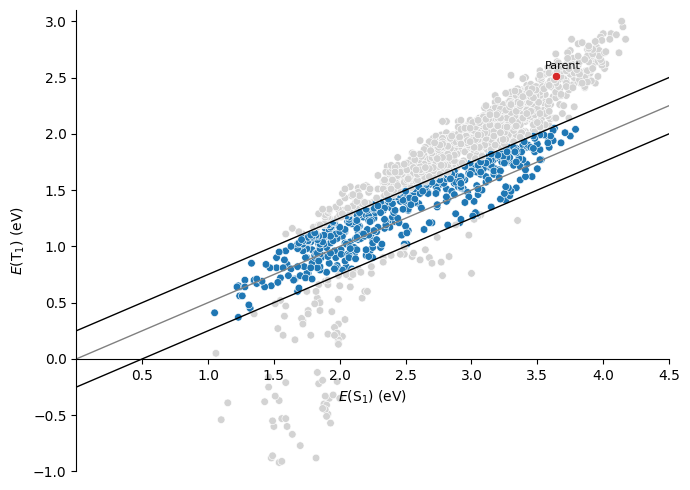

In [39]:
fig4, ax3 = plt.subplots(figsize=(7,5))

delta = 0.5

x = np.linspace(0.0,table2['S1'].max()+delta)

up      = list(map(lambda x : (x+0.5)*0.5, x))
bottom  = list(map(lambda x : (x-0.5)*0.5, x))

in_outlist = [0  if yy >= (table2['S1'].values[n]+0.5)*0.5  or yy <= (table2['S1'].values[n]-0.5)*0.5 else 1 for n,yy in enumerate(table2['T1'])  ];

table2 = table2.assign(in_out=in_outlist)

sns.scatterplot(data=table2, x = 'S1',y = 'T1',s=30,  ax=ax3, hue='in_out', legend=False, palette=['lightgray','tab:blue'])
## sns.scatterplot(data=table2, x = 'S1',y = 'T1',s=30,  ax=ax3, hue='in_out', legend=False, palette=['#7FA6E8','tab:blue'])

sys_name='CH_CH_CH'
pp =table2[ table2['System']== sys_name ]
display(type(pp))
sns.scatterplot(data=pp, x='S1', y='T1',color='tab:red', zorder=100, markers='o')
##ax3.scatter(pp['S1'],pp['T1'], color='tab:red',zorder=100, marker='o')

x = np.linspace(0.0,table2['S1'].max()+delta)
bb  = list(map(lambda x : x*0.5,x))
ax3.plot(x,bb,lw=1,c='grey')

ax3.set_xlabel(r'$E$(S$_1$) (eV)')
ax3.set_ylabel(r'$E$(T$_1$) (eV)')

ax3.plot(x,up,lw=1,c='black') #c='tab:orange'
ax3.plot(x,bottom,lw=1,c='black') #c='tab:purple'

##label highlighted point
dd=0.05
ax3.annotate('Parent', xy=(pp['S1']+dd, pp['T1']+dd),va='bottom', ha='center', fontsize=8) #'{}'.format(sys_name) instead of Parent

## ax3.axhline(0.0, lw=0.75,c='gray')
ax3.set_xlim(xmin=0.0,xmax=4.5)
ax3.set_ylim(ymin=-1,ymax=3.1)
ax3.spines['right'].set_visible(False)
ax3.spines['top'].set_visible(False)

##move x axis
ax3.spines['bottom'].set_position('zero')

ax3.xaxis.set_ticks_position('bottom')
ax3.set_xticks(np.linspace(0.5,4.5,num=9));
plt.tight_layout()

#fig4.savefig('./scatter_range.png',format='png',dpi=350)

['CNOO', 'CBFF', 'COH', 'CCN', 'others']

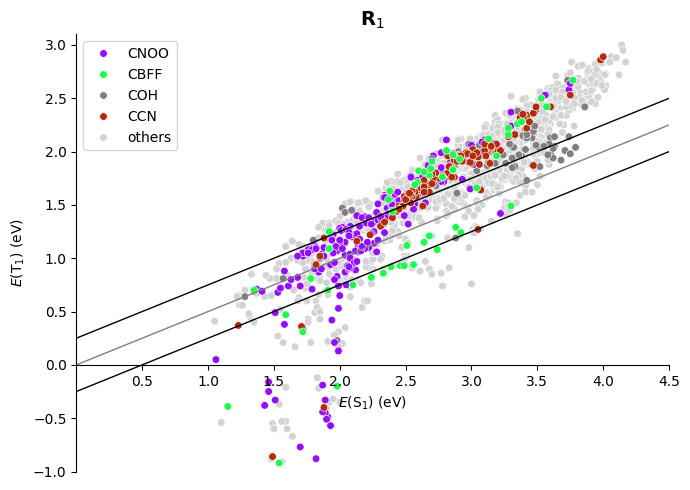

In [40]:
fig5, ax4 = plt.subplots(figsize=(7,5))

delta = 0.5

x = np.linspace(0.0,table2['S1'].max()+delta)

up      = list(map(lambda x : (x+0.5)*0.5, x))
bottom  = list(map(lambda x : (x-0.5)*0.5, x))

## in_outlist = [0  if yy >= (table2['S1'].values[n]+0.5)*0.5  or yy <= (table2['S1'].values[n]-0.5)*0.5 else 1 for n,yy in enumerate(table2['T1'])  ];

## table2 = table2.assign(in_out=in_outlist)

pos = 'pos6'
subs  = ['CNOO','CBFF','COH','CCN', 'others']
##subs  = ['CNOO','CBFF','COH','CCN', 'others']
##subs  = ['COH', 'CCHHH','CBFF','CBHH', 'others']
##subs  = ['CNMeMe','CNHH','CCFFF','CH', 'CBHH','COH', 'others']
##subs  = ['CSiHHH', 'CNHH', 'CCN', 'others']
##subs  = ['CH','CBFF','CCFFF', 'CF', 'CCN', 'others']
##subs  = ['CH', 'CNOO', 'CNHH', 'others']
colors2 = {'others':'lightgray',
         'CNHH': '#2834F4',
         'CH': '#FDA603',
         'CNMeMe': '#36A510',
         'CSiHHH': '#F91D0F',
         'CNOO': '#920FF9',
         'CCFFF': '#684507',
         'CCl': '#E914DC',
         'COH': '#827D82',
         'CSH': '#FEEF03',
         'CF': '#05E4FA',
         'CCN': '#B12C0B',
         'CCHHH': '#FADA9E',
         'CBFF': '#1EF94D',
         'CBHH': '#926BFA',
         'COCHHH': '#FC7EC1',
         }

aux = [i  if  i in subs else 'others' for i in table2[pos]]
pp2 = table2[:]
pp2[pos] = aux
pp2.sort_values(by=pos, inplace=True, ascending=False)

##scatter plot taking into account the substituents in the list subs
sns.scatterplot(data=pp2, x = 'S1',y = 'T1',s=30, ax=ax4,legend=True, palette=colors2, hue=pos, hue_order=subs) #palette=sns.color_palette("tab10")[:len(subs)

ax4.legend()

display(subs)

x = np.linspace(0.0,table2['S1'].max()+delta)
bb  = list(map(lambda x : x*0.5,x))
ax4.plot(x,bb,lw=1,c='grey')

ax4.set_xlabel(r'$E$(S$_1$) (eV)')
ax4.set_ylabel(r'$E$(T$_1$) (eV)')
ax4.set_title('R$_1$',fontweight="bold", fontsize=14)

ax4.plot(x,up,lw=1,c='black') #c='tab:orange'
ax4.plot(x,bottom,lw=1,c='black') #c='tab:purple'

ax4.set_xlim(xmin=0.0,xmax=4.5)
ax4.set_ylim(ymin=-1,ymax=3.1)
ax4.spines['right'].set_visible(False)
ax4.spines['top'].set_visible(False)

##move x axis
ax4.spines['bottom'].set_position('zero')

ax4.xaxis.set_ticks_position('bottom')
ax4.set_xticks(np.linspace(0.5,4.5,num=9));
plt.tight_layout()

#fig5.savefig('./scatter_select_pos1.png',format='png',dpi=350)

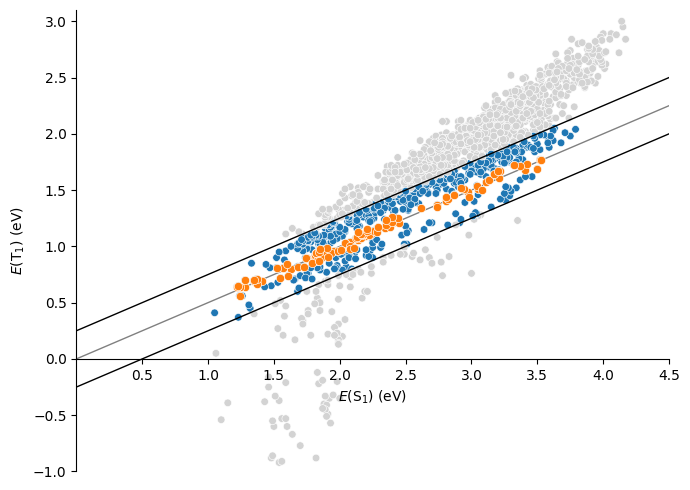

In [41]:
fig6, ax5 = plt.subplots(figsize=(7,5))

delta = 0.5

x = np.linspace(0.0,table2['S1'].max()+delta)

up      = list(map(lambda x : (x+0.5)*0.5, x))
bottom  = list(map(lambda x : (x-0.5)*0.5, x))

in_outlist = [0  if yy >= (table2['S1'].values[n]+0.5)*0.5  or yy <= (table2['S1'].values[n]-0.5)*0.5 else 1 for n,yy in enumerate(table2['T1'])  ];

table2 = table2.assign(in_out=in_outlist)

sns.scatterplot(data=table2, x = 'S1',y = 'T1',s=30,  ax=ax5, hue='in_out', legend=False, palette=['lightgray','tab:blue'])
## sns.scatterplot(data=table2, x = 'S1',y = 'T1',s=30,  ax=ax5, hue='in_out', legend=False, palette=['#7FA6E8','tab:blue'])

sns.scatterplot(data=sorted_table2.iloc[:100], x='S1', y='T1',color='tab:orange', zorder=100, markers='o')  #iloc because the indices are not in order but python is not taking the order shoed in the table, it uses the intenar correct order from 0 to x

x = np.linspace(0.0,table2['S1'].max()+delta)
bb  = list(map(lambda x : x*0.5,x))
ax5.plot(x,bb,lw=1,c='grey')

ax5.set_xlabel(r'$E$(S$_1$) (eV)')
ax5.set_ylabel(r'$E$(T$_1$) (eV)')

ax5.plot(x,up,lw=1,c='black') #c='tab:orange'
ax5.plot(x,bottom,lw=1,c='black') #c='tab:purple'

##label highlighted point
##dd=0.05
##ax5.annotate('Parent', xy=(pp['S1']+dd, pp['T1']+dd),va='bottom', ha='center', fontsize=8) #'{}'.format(sys_name) instead of Parent

## ax5.axhline(0.0, lw=0.75,c='gray')
ax5.set_xlim(xmin=0.0,xmax=4.5)
ax5.set_ylim(ymin=-1,ymax=3.1)
ax5.spines['right'].set_visible(False)
ax5.spines['top'].set_visible(False)

##move x axis
ax5.spines['bottom'].set_position('zero')

ax5.xaxis.set_ticks_position('bottom')
ax5.set_xticks(np.linspace(0.5,4.5,num=9));
plt.tight_layout()

#fig6.savefig('./scatter_100best.png',format='png',dpi=350)

pandas.core.frame.DataFrame

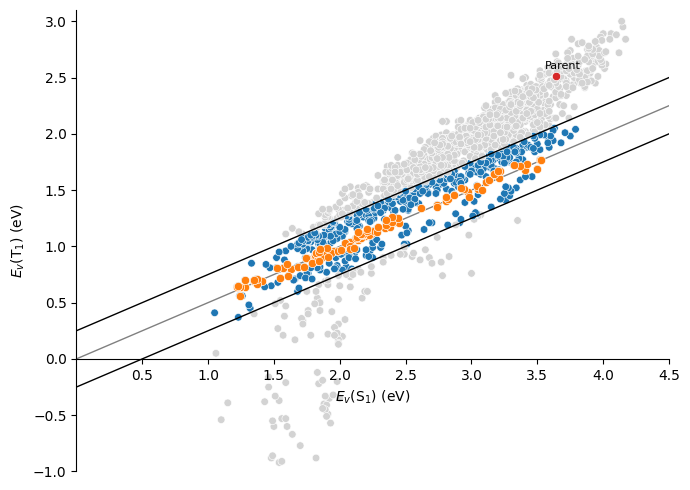

In [42]:
fig6, ax5 = plt.subplots(figsize=(7,5))

delta = 0.5

x = np.linspace(0.0,table2['S1'].max()+delta)

up      = list(map(lambda x : (x+0.5)*0.5, x))
bottom  = list(map(lambda x : (x-0.5)*0.5, x))

in_outlist = [0  if yy >= (table2['S1'].values[n]+0.5)*0.5  or yy <= (table2['S1'].values[n]-0.5)*0.5 else 1 for n,yy in enumerate(table2['T1'])  ];

table2 = table2.assign(in_out=in_outlist)

sns.scatterplot(data=table2, x = 'S1',y = 'T1',s=30,  ax=ax5, hue='in_out', legend=False, palette=['lightgray','tab:blue'])
## sns.scatterplot(data=table2, x = 'S1',y = 'T1',s=30,  ax=ax5, hue='in_out', legend=False, palette=['#7FA6E8','tab:blue'])

sys_name='CH_CH_CH'
pp =table2[ table2['System']== sys_name ]
display(type(pp))
sns.scatterplot(data=pp, x='S1', y='T1',color='tab:red', zorder=100, markers='o')
##ax3.scatter(pp['S1'],pp['T1'], color='tab:red',zorder=100, marker='o')

sns.scatterplot(data=sorted_table2.iloc[:100], x='S1', y='T1',color='tab:orange', zorder=100, markers='o')  #iloc because the indices are not in order but python is not taking the order shoed in the table, it uses the intenar correct order from 0 to x

x = np.linspace(0.0,table2['S1'].max()+delta)
bb  = list(map(lambda x : x*0.5,x))
ax5.plot(x,bb,lw=1,c='grey')

ax5.set_xlabel(r'$E_v$(S$_1$) (eV)')
ax5.set_ylabel(r'$E_v$(T$_1$) (eV)')

ax5.plot(x,up,lw=1,c='black') #c='tab:orange'
ax5.plot(x,bottom,lw=1,c='black') #c='tab:purple'

#label highlighted point
dd=0.05
ax5.annotate('Parent', xy=(pp['S1']+dd, pp['T1']+dd),va='bottom', ha='center', fontsize=8) #'{}'.format(sys_name) instead of Parent

## ax5.axhline(0.0, lw=0.75,c='gray')
ax5.set_xlim(xmin=0.0,xmax=4.5)
ax5.set_ylim(ymin=-1,ymax=3.1)
ax5.spines['right'].set_visible(False)
ax5.spines['top'].set_visible(False)

##move x axis
ax5.spines['bottom'].set_position('zero')

ax5.xaxis.set_ticks_position('bottom')
ax5.set_xticks(np.linspace(0.5,4.5,num=9));
plt.tight_layout()

fig6.savefig('./Database_best_v3.png',format='png',dpi=350)

In [43]:
def myfunc3(df,base='',levels=['up','bottom','middle']):
    group=[]
    for n,yy in enumerate(df[base]): #df in general->later you will name the dataframe you need, base ->the column you will apply the function, later you will specify which one
        if yy >= (df['S1'].values[n]+0.5)*0.5:
            group.append(levels[0])
        elif yy <= (df['S1'].values[n]-0.5)*0.5:
            group.append(levels[1])
        else:
            group.append(levels[2])

    return group

sorted_table2["Group"]= myfunc3(sorted_table2,base='T1',levels=['up','bottom','middle'])
sorted_table2
##sorted_table2[sorted_table2['Group']=='middle']['Function']  # list only systems in the middle part and only the function column of these systems


,System,SCF Energy,S1,S2,S3,T1,T2,T3,Function,|Function|,pos1,pos2,pos3,pos4,pos5,pos6,System_num.pos,Fulvene,Group
1312,CNOO_CBHH_COH,-842.438155,1.28,2.74,3.53,0.64,2.31,2.54,0.00,0.00,NO$_2$,BH$_2$,OH,NO$_2$,BH$_2$,OH,3,NO$_2$_BH$_2$_OH_NO$_2$_BH$_2$_OH,middle
1461,CNOO_COH_COH_CCN_CH_CNOO,-883.774750,1.81,3.72,3.83,0.90,2.40,2.55,0.00,0.00,NO$_2$,OH,OH,CN,H,NO$_2$,6,NO$_2$_OH_OH_CN_H_NO$_2$,middle
362,CNOO_CCHHH_CNMeMe_CCFFF_CNHH_CNOO,-1206.773330,2.08,3.67,3.83,1.04,2.59,2.96,0.00,0.00,NO$_2$,Me,NMe$_2$,CF$_3$,NH$_2$,NO$_2$,6,NO$_2$_Me_NMe$_2$_CF$_3$_NH$_2$_NO$_2$,middle
1041,COH_CSH_COH_CSiHHH_CNOO_CNMeMe,-1409.894916,3.21,3.64,4.03,1.61,2.52,3.15,0.00,0.00,OH,SH,OH,SiH$_3$,NO$_2$,NMe$_2$,6,OH_SH_OH_SiH$_3$_NO$_2$_NMe$_2$,middle
369,CNOO_CCHHH_CNMeMe_CCHHH_CNHH_CNOO,-909.039796,2.14,3.66,3.74,1.06,2.54,2.70,0.01,0.01,NO$_2$,Me,NMe$_2$,Me,NH$_2$,NO$_2$,6,NO$_2$_Me_NMe$_2$_Me_NH$_2$_NO$_2$,middle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256,COH_COH_CNHH_CNOO_CBFF_CSiHHH,-1157.195066,1.48,3.27,3.66,-0.88,1.88,3.42,3.24,3.24,OH,OH,NH$_2$,NO$_2$,BF$_2$,SiH$_3$,6,OH_OH_NH$_2$_NO$_2$_BF$_2$_SiH$_3$,bottom
657,CNOO_CBFF_CNMeMe_CNHH_CCFFF_CNOO,-1391.540547,1.70,3.22,3.40,-0.77,2.25,2.64,3.25,3.25,NO$_2$,BF$_2$,NMe$_2$,NH$_2$,CF$_3$,NO$_2$,6,NO$_2$_BF$_2$_NMe$_2$_NH$_2$_CF$_3$_NO$_2$,bottom
279,COH_COH_CNHH_CNOO_CBFF_CBFF,-1090.598265,1.54,3.30,3.68,-0.92,2.02,3.37,3.37,3.37,OH,OH,NH$_2$,NO$_2$,BF$_2$,BF$_2$,6,OH_OH_NH$_2$_NO$_2$_BF$_2$_BF$_2$,bottom
280,COH_COH_CNHH_CNOO_CBFF_CBHH,-891.955693,1.56,3.25,3.56,-0.91,1.94,3.26,3.38,3.38,OH,OH,NH$_2$,NO$_2$,BF$_2$,BH$_2$,6,OH_OH_NH$_2$_NO$_2$_BF$_2$_BH$_2$,bottom


In [44]:
table_mid=sorted_table2[(sorted_table2['Group']=='middle') & (sorted_table2['System_num.pos']==6)]
len(table_mid) #how many systems from the middle range are coming from the 6 sites

474

STATISTICAL ANALYSIS
    IQR (Interquartile range) = Q3 - Q1
    'low' outliers: Q1-1.5*IQR
    'high' outliers: Q3+1.5*IQR
    display(table.loc[(table["Function"]<= low outlier num)])
    display(table.loc[(high outlier num<= table['Function'])])

In [45]:
sorted_table2.describe()

,SCF Energy,S1,S2,S3,T1,T2,T3,Function,|Function|,System_num.pos
count,1658.000000,1658.000000,1658.000000,1658.000000,1658.000000,1658.000000,1658.000000,1658.000000,1658.000000,1658.000000
mean,-1178.797923,2.814318,3.968643,4.412955,1.686496,2.563010,3.669119,-0.558739,0.782467,5.644753
std,348.206064,0.626612,0.455030,0.537119,0.611584,0.302706,0.827736,0.731766,0.485012,1.046233
min,-2356.648320,1.050000,2.520000,3.060000,-0.920000,1.290000,2.290000,-1.910000,0.000000,2.000000
25%,-1409.717050,2.372500,3.690000,3.960000,1.370000,2.400000,2.820000,-1.000000,0.440000,6.000000
50%,-1147.331202,2.910000,3.890000,4.340000,1.790000,2.560000,3.770000,-0.690000,0.750000,6.000000
75%,-928.975354,3.290000,4.250000,4.760000,2.070000,2.760000,4.340000,-0.320000,1.040000,6.000000
max,-232.141500,4.170000,5.710000,7.060000,3.000000,3.550000,6.030000,3.580000,3.580000,6.000000


In [46]:
#IQR(Function)
-0.320000-(-1.010000)

0.69

In [47]:
#Low outliers
-1.010000-1.5*0.69

-2.045

In [48]:
#High outliers
-0.320000+1.5*0.69

0.7149999999999999

In [74]:
display(table2.loc[(table2['Function']<= -2.045)])

,System,SCF Energy,S1,S2,S3,T1,T2,T3,Function,|Function|,pos1,pos2,pos3,pos4,pos5,pos6,System_num.pos,in_out


In [50]:
display(table2.loc[(0.7149999999999999<= table2['Function'])])
len(table2.loc[(0.7149999999999999<= table2['Function'])])

,System,SCF Energy,S1,S2,S3,T1,T2,T3,Function,|Function|,pos1,pos2,pos3,pos4,pos5,pos6,System_num.pos,in_out
30,CNOO_COH_CNOO_CNHH_CH_CNHH,-827.067976,2.17,3.39,3.92,0.54,2.44,2.98,1.08,1.08,CNOO,COH,CNOO,CNHH,CH,CNHH,6,0
35,CNOO_COH_CBFF_CNHH_CH_CNHH,-846.665386,2.19,3.38,3.95,0.60,2.44,3.05,0.99,0.99,CNOO,COH,CBFF,CNHH,CH,CNHH,6,0
36,CNOO_COH_CBHH_CNHH_CH_CNHH,-648.023260,2.21,3.35,3.95,0.60,2.36,3.09,1.02,1.02,CNOO,COH,CBHH,CNHH,CH,CNHH,6,0
70,CNOO_CNHH_CNOO_CNHH_CH_CNHH,-807.215468,2.24,3.53,3.69,0.76,2.53,2.87,0.72,0.72,CNOO,CNHH,CNOO,CNHH,CH,CNHH,6,0
185,CF_CNMeMe_CNOO_COH_CNOO_CNMeMe,-1083.504545,2.98,3.69,4.02,1.10,2.64,2.95,0.77,0.77,CF,CNMeMe,CNOO,COH,CNOO,CNMeMe,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1587,CNOO_COH_COH_CCN_COH_CNOO,-958.997520,1.58,3.84,3.97,0.38,2.64,2.73,0.81,0.81,CNOO,COH,COH,CCN,COH,CNOO,6,0
1654,CNOO_COH_CNHH_CCN_CBFF_CNOO,-1087.995600,1.46,3.52,3.77,-0.16,2.48,2.64,1.78,1.78,CNOO,COH,CNHH,CCN,CBFF,CNOO,6,0
1655,CNOO_COH_CNHH_CCN_CH_CNOO,-863.923510,1.46,3.58,3.77,-0.25,2.49,2.60,1.96,1.96,CNOO,COH,CNHH,CCN,CH,CNOO,6,0
1656,CNOO_COH_CNMeMe_CCN_CH_CNOO,-942.505010,1.51,3.54,3.73,-0.33,2.46,2.67,2.17,2.17,CNOO,COH,CNMeMe,CCN,CH,CNOO,6,0


77